# Deep Learning - Elektrikli Araç Menzil Tahmini (MLP)

Bu projede Keras ile çok katmanlı bir yapay sinir ağı (MLP) kurup elektrikli aracın menzilini (mil) tahmin edeceğiz.

In [1]:
import pandas as pd
import numpy as np
pd.set_option('display.max_columns',100)

import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [3]:
df=pd.read_csv('export.csv')

In [4]:
df=df[df['Electric Range']>0]
df=df[['Model Year','Make','Model','Electric Vehicle Type','Electric Range']].dropna()
df.shape

(103444, 5)

In [5]:
en_sik_model=df['Model'].value_counts().head(50).index
df['Model']=df['Model'].where(df['Model'].isin(en_sik_model),'OTHER')

In [6]:
df=df.sample(n=min(50000,len(df)),random_state=42)

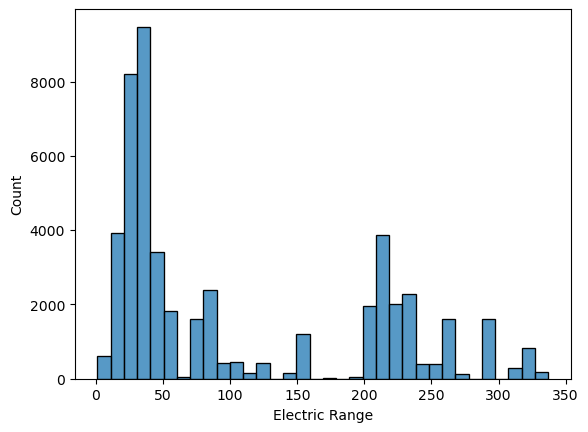

In [7]:
sns.histplot(df['Electric Range']);

In [8]:
x=df.drop('Electric Range',axis=1)
y=df['Electric Range']

In [9]:
secenekler={
    'Make':sorted(df['Make'].unique().tolist()),
    'Model':sorted(df['Model'].unique().tolist()),
    'Type':sorted(df['Electric Vehicle Type'].unique().tolist()),
}
ozet={'yil_ort':float(x['Model Year'].mean()),'yil_std':float(x['Model Year'].std())}

In [10]:
x['Model Year']=(x['Model Year']-ozet['yil_ort'])/ozet['yil_std']
x=pd.get_dummies(x,drop_first=True).astype('float32')
x.shape

(50000, 90)

In [11]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=.15,random_state=42)

In [12]:
model=keras.Sequential([
    layers.Input(shape=(x_train.shape[1],)),
    layers.Dense(64,activation='relu'),
    layers.Dense(32,activation='relu'),
    layers.Dense(1)
])
model.compile(optimizer='adam',loss='mse',metrics=['mae'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │           5,824 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,937 (31.00 KB)

 Trainable params: 7,937 (31.00 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
gecmis=model.fit(x_train.values,y_train.values,validation_split=.15,epochs=30,batch_size=128,verbose=1)

Epoch 1/30
283/283 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 12104.2051 - mae: 73.0081 - val_loss: 1638.5471 - val_mae: 27.1069
Epoch 2/30
283/283 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 740.5193 - mae: 16.9400 - val_loss: 530.2513 - val_mae: 13.6805
Epoch 3/30
283/283 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 419.4386 - mae: 11.6445 - val_loss: 381.6468 - val_mae: 10.9673
Epoch 4/30
283/283 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 313.7701 - mae: 9.6680 - val_loss: 286.1850 - val_mae: 9.1714
Epoch 5/30
283/283 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 237.2390 - mae: 8.1690 - val_loss: 216.5306 - val_mae: 7.8996
Epoch 6/30
283/283 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 180.9894 - mae: 7.0036 - val_loss: 164.1193 - val_mae: 6.7653
Epoch 7/30
283/283 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 143.8764 - mae: 6.0618 - val_loss: 136.7369 - val_mae: 5.8775
Epoch 8/30
283/283 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 124.3034 - mae: 5.3775 - val_loss: 122.7974 - val_mae: 5.2262
Epoch 9/30
28

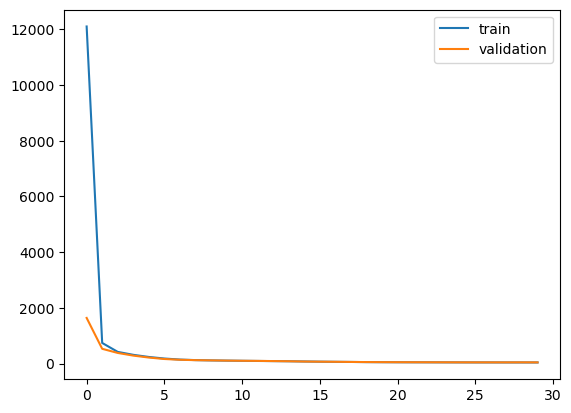

In [14]:
plt.plot(gecmis.history['loss'],label='train')
plt.plot(gecmis.history['val_loss'],label='validation')
plt.legend()
plt.show()

In [15]:
from sklearn.metrics import r2_score, mean_squared_error
tahmin=model.predict(x_test.values).flatten()
print('R2:',r2_score(y_test,tahmin))
print('RMSE:',np.sqrt(mean_squared_error(y_test,tahmin)))

235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
R2: 0.9963127362676308
RMSE: 5.894089457347864


### Modeli kaydetme

In [16]:
import pickle
model.save('ev_menzil_model.keras')
pickle.dump(list(x.columns),open('menzil_sutunlar.pkl','wb'))
pickle.dump(secenekler,open('menzil_secenekler.pkl','wb'))
pickle.dump(ozet,open('menzil_ozet.pkl','wb'))